# Pit · Bill (Hamilton) · Lost
## Potential Wells · Hamiltonian Mechanics · Signal Loss

| § | Topic | Key result |
|---|---|---|
| 1 | Potential wells | Infinite well: $E_n = \frac{n^2\pi^2\hbar^2}{2mL^2}$; finite well numerically |
| 2 | Morse potential | Anharmonic oscillator; dissociation energy; overtones |
| 3 | Hamilton's principle | $\delta\int L\,dt = 0$; Euler-Lagrange equations |
| 4 | Hamiltonian phase space | $(q,p)$ trajectories; Liouville; Poisson brackets |
| 5 | Lost: signal/decoherence | Fiber dB/km budget; shot-noise SNR; qubit T₁/T₂ |


## §1 Potential Wells — Infinite and Finite Square Well

**Infinite square well** (particle in a box): $V=0$ inside $[0,L]$, $V=\infty$ outside.

$$\psi_n(x) = \sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x}{L}\right), \qquad E_n = \frac{n^2\pi^2\hbar^2}{2mL^2}$$

**Finite square well**: solve numerically via shooting method.
For even solutions: $k\tan(kL/2) = \kappa$ where $k^2 = 2mE/\hbar^2$, $\kappa^2 = 2m(V_0-E)/\hbar^2$.


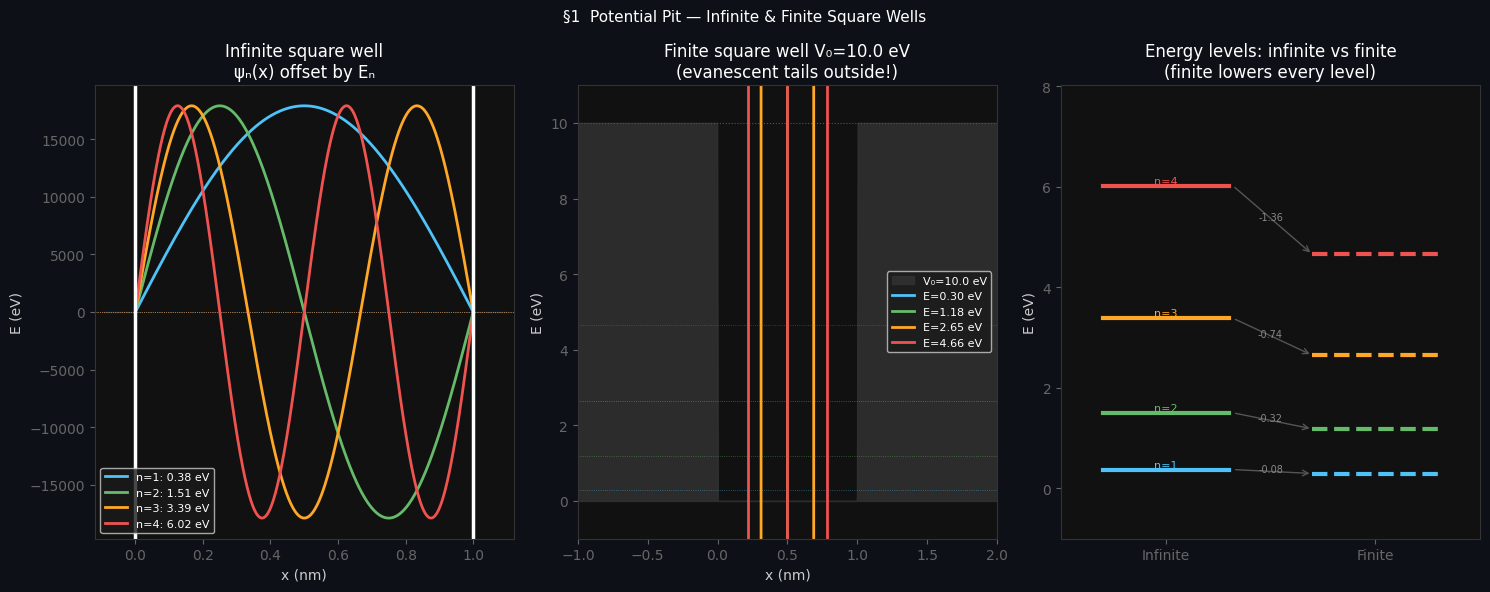

Infinite well energies (eV): ['0.376', '1.506', '3.388', '6.022']
Finite   well energies (eV): ['0.297', '1.185', '2.649', '4.657']
Ratio E2/E1 = 3.9860  (infinite: 4.0000)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.optimize import brentq

hbar = 1.055e-34; me = 9.109e-31
eV   = 1.602e-19

# ── Infinite square well ──────────────────────────────────────────────────────
L = 1e-9    # 1 nm well
n_states = 6
E_inf = [(n**2 * np.pi**2 * hbar**2) / (2*me*L**2) / eV for n in range(1, n_states+1)]

x = np.linspace(0, L, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
colors_n = ['#4fc3f7','#66bb6a','#ffa726','#ef5350','#b39ddb','#ffcc02']
for n, (En, col) in enumerate(zip(E_inf[:4], colors_n), 1):
    psi = np.sqrt(2/L) * np.sin(n*np.pi*x/L)
    offset = En
    ax.plot(x*1e9, psi*0.4 + offset, color=col, lw=2, label=f'n={n}: {En:.2f} eV')
    ax.axhline(En, color=col, lw=0.6, ls=':', alpha=0.5)

ax.axvline(0,   color='white', lw=2.5)
ax.axvline(L*1e9, color='white', lw=2.5)
ax.fill_between([-0.1, 0], -1, 25, color='#333', alpha=0.8)
ax.fill_between([L*1e9, L*1e9+0.1], -1, 25, color='#333', alpha=0.8)
ax.set_xlabel('x (nm)', color='#ccc'); ax.set_ylabel('E (eV)', color='#ccc')
ax.set_title('Infinite square well\nψₙ(x) offset by Eₙ', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.set_xlim(-0.12, L*1e9+0.12)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Finite square well: shooting / matrix method ──────────────────────────────
# Use finite difference on [-2L, 3L]
N_fd = 1000
x_fd = np.linspace(-2*L, 3*L, N_fd)
dx   = x_fd[1]-x_fd[0]
V0_eV = 10.0   # eV well depth
V_fd  = np.where((x_fd >= 0) & (x_fd <= L), 0.0, V0_eV*eV)

# Tridiagonal Hamiltonian
diag = hbar**2/(me*dx**2) + V_fd
off  = -hbar**2/(2*me*dx**2) * np.ones(N_fd-1)
vals, vecs = eigh_tridiagonal(diag, off, select='i', select_range=(0, 5))

ax2 = axes[1]
V_plot = np.where((x_fd >= 0) & (x_fd <= L), 0.0, V0_eV)
ax2.fill_between(x_fd*1e9, 0, V_plot, color='#333', alpha=0.8, label=f'V₀={V0_eV} eV')
ax2.axhline(V0_eV, color='#555', lw=0.8, ls=':')

for i, (Ei, col) in enumerate(zip(vals[:4]/eV, colors_n)):
    psi = vecs[:,i]
    norm = np.sqrt(np.trapezoid(psi**2, x_fd))
    psi_n = psi / norm
    ax2.plot(x_fd*1e9, psi_n*0.3e9 + Ei, color=col, lw=2, label=f'E={Ei:.2f} eV')
    ax2.axhline(Ei, color=col, lw=0.6, ls=':', alpha=0.5)

ax2.set_xlabel('x (nm)', color='#ccc'); ax2.set_ylabel('E (eV)', color='#ccc')
ax2.set_title(f'Finite square well V₀={V0_eV} eV\n(evanescent tails outside!)', color='white')
ax2.set_xlim(-1, 2); ax2.set_ylim(-1, V0_eV+1)
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Energy level comparison ────────────────────────────────────────────────────
ax3 = axes[2]
E_finite = vals[:4]/eV
x_inf  = [0.1, 0.4]; x_fin  = [0.6, 0.9]
for n, (Ei, Ef, col) in enumerate(zip(E_inf[:4], E_finite, colors_n), 1):
    ax3.plot(x_inf, [Ei, Ei], color=col, lw=3)
    ax3.plot(x_fin, [Ef, Ef], color=col, lw=3, ls='--')
    ax3.text(0.25, Ei, f'n={n}', ha='center', va='bottom', color=col, fontsize=8)
    ax3.annotate('', (0.6, Ef), (0.4+0.01, Ei),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1))
    ax3.text(0.5, (Ei+Ef)/2, f'{Ef-Ei:+.2f}', ha='center', color='#888', fontsize=7)

ax3.set_xlim(0, 1.0); ax3.set_ylim(-1, E_inf[3]+2)
ax3.set_xticks([0.25, 0.75])
ax3.set_xticklabels(['Infinite', 'Finite'], color='#ccc', fontsize=10)
ax3.set_ylabel('E (eV)', color='#ccc')
ax3.set_title('Energy levels: infinite vs finite\n(finite lowers every level)', color='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§1  Potential Pit — Infinite & Finite Square Wells', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/potential_wells.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Infinite well energies (eV):", [f"{e:.3f}" for e in E_inf[:4]])
print("Finite   well energies (eV):", [f"{e:.3f}" for e in E_finite])
print(f"Ratio E2/E1 = {E_finite[1]/E_finite[0]:.4f}  (infinite: {4.0:.4f})")


## §2 Morse Potential — Anharmonic Oscillator

$$V(r) = D_e\left(1 - e^{-a(r-r_e)}\right)^2$$

Taylor expand about $r_e$:
$$V \approx D_e a^2(r-r_e)^2 - D_e a^3(r-r_e)^3 + \tfrac{7}{12}D_e a^4(r-r_e)^4 + \cdots$$

The quadratic term gives harmonic frequency $\omega_e = a\sqrt{2D_e/m}$.
Cubic/quartic terms → anharmonic corrections, overtone frequencies:

$$E_n = \hbar\omega_e\!\left(n+\tfrac{1}{2}\right) - \frac{\hbar^2\omega_e^2}{4D_e}\!\left(n+\tfrac{1}{2}\right)^2$$


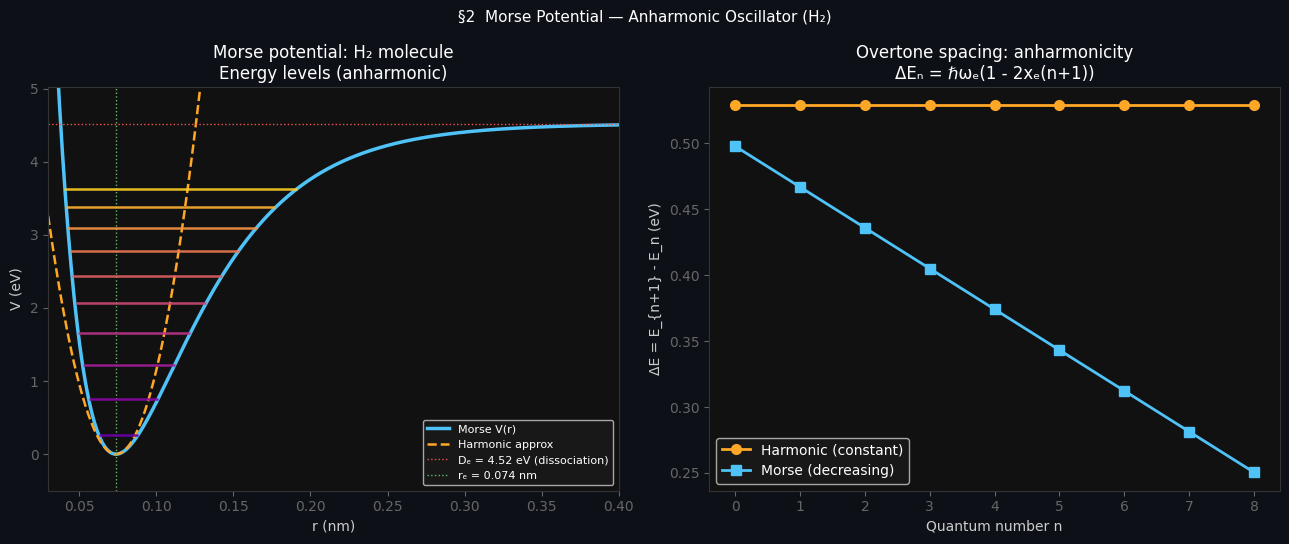

H₂ harmonic freq: ωₑ/2π = 127.80 THz  = 43 cm⁻¹ (exp: 4401 cm⁻¹)
Anharmonicity xₑ = 0.02925
Max bound states: n ≤ 16


In [2]:
import numpy as np, matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal

eV = 1.602e-19; hbar = 1.055e-34; amu = 1.66e-27

# H2 molecule parameters
De_eV = 4.52    # dissociation energy
re_nm = 0.074   # equilibrium bond length
mu    = 0.5 * 1.008 * amu   # reduced mass H2
a_inv = 1.93e10  # m^-1 (Morse parameter for H2)

De = De_eV * eV
r  = np.linspace(0.03e-9, 0.4e-9, 600)
V_morse = De * (1 - np.exp(-a_inv*(r - re_nm*1e-9)))**2

# Harmonic approximation
k_eff = 2*De*a_inv**2
V_harm = 0.5 * k_eff * (r - re_nm*1e-9)**2

# Exact Morse energy levels
omega_e = a_inv * np.sqrt(2*De/mu)
xe      = hbar*omega_e / (4*De)   # anharmonicity constant
n_max   = int(0.5/xe - 0.5)       # max bound state
n_vals  = np.arange(min(n_max, 10))
E_morse = hbar*omega_e*(n_vals+0.5) - hbar*omega_e*xe*(n_vals+0.5)**2
E_harm  = hbar*omega_e*(n_vals+0.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(r*1e9, V_morse/eV, color='#4fc3f7', lw=2.5, label='Morse V(r)')
ax.plot(r*1e9, V_harm/eV,  color='#ffa726', lw=1.8, ls='--', label='Harmonic approx')
ax.axhline(De_eV, color='#ef5350', lw=1, ls=':', label=f'Dₑ = {De_eV} eV (dissociation)')
ax.axvline(re_nm, color='#66bb6a', lw=1, ls=':', label=f'rₑ = {re_nm} nm')

colors_m = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_vals)))
for n, En, col in zip(n_vals, E_morse/eV, colors_m):
    # Classical turning points
    def V_minus_E(r_val):
        return De*(1-np.exp(-a_inv*(r_val-re_nm*1e-9)))**2/eV - En
    try:
        r_l = brentq(V_minus_E, 0.03e-9, re_nm*1e-9)
        r_r = brentq(V_minus_E, re_nm*1e-9, 0.35e-9)
        ax.hlines(En, r_l*1e9, r_r*1e9, color=col, lw=1.8, alpha=0.9)
    except:
        pass

ax.set_xlabel('r (nm)', color='#ccc'); ax.set_ylabel('V (eV)', color='#ccc')
ax.set_title('Morse potential: H₂ molecule\nEnergy levels (anharmonic)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.set_ylim(-0.5, De_eV+0.5); ax.set_xlim(0.03, 0.4)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Overtone shifts
ax2 = axes[1]
dE_harm  = np.diff(E_harm/eV)    # harmonic: all equal
dE_morse = np.diff(E_morse/eV)   # Morse: decreasing
ax2.plot(n_vals[:-1], dE_harm,  'o-', color='#ffa726', lw=2, ms=7, label='Harmonic (constant)')
ax2.plot(n_vals[:-1], dE_morse, 's-', color='#4fc3f7', lw=2, ms=7, label='Morse (decreasing)')
ax2.set_xlabel('Quantum number n', color='#ccc')
ax2.set_ylabel('ΔE = E_{n+1} - E_n (eV)', color='#ccc')
ax2.set_title('Overtone spacing: anharmonicity\nΔEₙ = ℏωₑ(1 - 2xₑ(n+1))', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle('§2  Morse Potential — Anharmonic Oscillator (H₂)', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/morse.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

from scipy.optimize import brentq
print(f"H₂ harmonic freq: ωₑ/2π = {omega_e/(2*np.pi)/1e12:.2f} THz  "
      f"= {omega_e/(2*np.pi)*3.336e-11*1e-2:.0f} cm⁻¹ (exp: 4401 cm⁻¹)")
print(f"Anharmonicity xₑ = {xe:.5f}")
print(f"Max bound states: n ≤ {n_max}")


## §3 Hamilton's Principle — $\delta S = 0$

**Action**: $S[q] = \int_{t_1}^{t_2} L(q,\dot{q},t)\,dt$

**Euler-Lagrange equations** (stationary action):
$$\frac{d}{dt}\frac{\partial L}{\partial\dot{q}_i} - \frac{\partial L}{\partial q_i} = 0$$

For a particle in potential $V$: $L = T - V = \frac{1}{2}m\dot{q}^2 - V(q)$

E-L → Newton: $m\ddot{q} = -\frac{\partial V}{\partial q}$ ✓

**Canonical momentum**: $p_i = \partial L/\partial\dot{q}_i$
**Hamiltonian**: $H = \sum_i p_i\dot{q}_i - L = T + V$ (total energy)


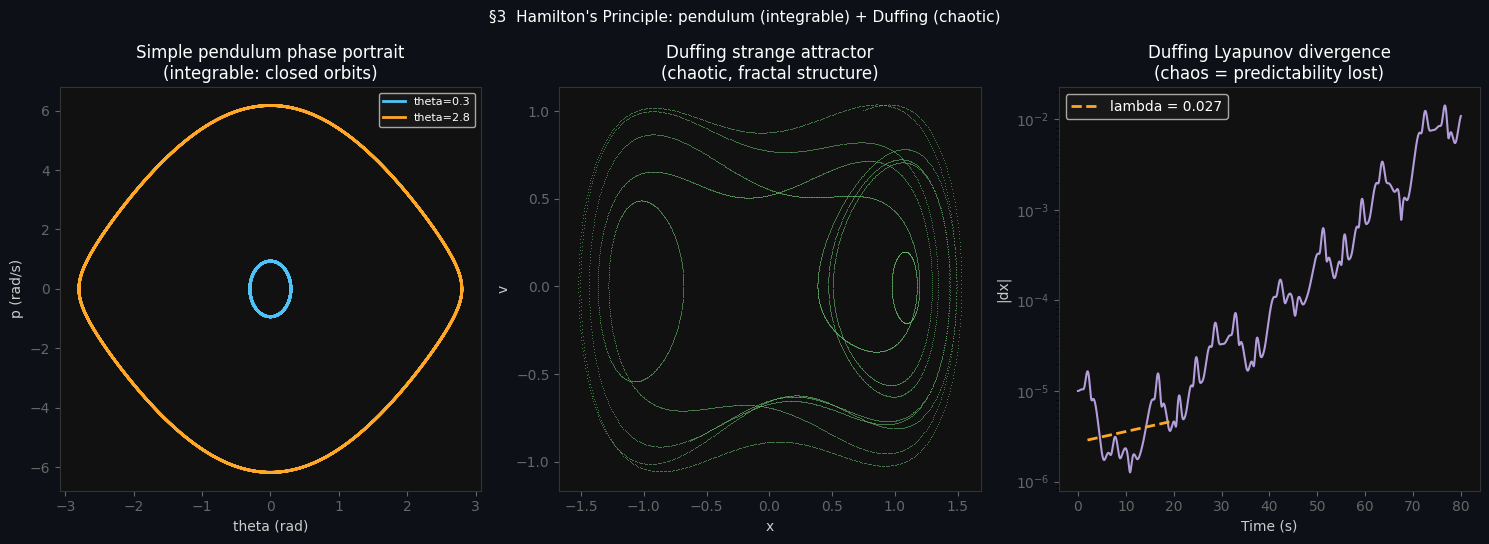

Duffing Lyapunov lambda = 0.027 (positive = chaos)
Simple pendulum: closed orbits (H conserved, integrable)


In [3]:
import numpy as np, matplotlib.pyplot as plt

def rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + dt/2, y + dt/2 * k1)
    k3 = f(t + dt/2, y + dt/2 * k2)
    k4 = f(t + dt,   y + dt    * k3)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def integrate(f, y0, t_arr):
    traj = np.zeros((len(t_arr), len(y0)))
    traj[0] = y0
    for i in range(1, len(t_arr)):
        traj[i] = rk4_step(f, t_arr[i-1], traj[i-1], t_arr[i]-t_arr[i-1])
    return traj

g, L = 9.81, 1.0
def pendulum(t, y):
    th, p = y
    return np.array([p, -(g/L)*np.sin(th)])

t = np.linspace(0, 20, 2000)
traj_small = integrate(pendulum, [0.3, 0.0], t)
traj_large = integrate(pendulum, [2.8, 0.0], t)

# Duffing oscillator  H = p^2/2 - x^2/2 + x^4/4 + gamma*x*cos(omega*t)
gamma=0.3; delta=0.15; omega_d=1.0; alpha=-1.0; beta=1.0
def duffing(t, y):
    x, v = y
    return np.array([v, -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega_d*t)])

t2 = np.linspace(0, 80, 8000)
d1 = integrate(duffing, [0.5, 0.0], t2)
d2 = integrate(duffing, [0.5+1e-5, 0.0], t2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(traj_small[:,0], traj_small[:,1], color='#4fc3f7', lw=2, label='theta=0.3')
ax.plot(traj_large[:,0], traj_large[:,1], color='#ffa726', lw=2, label='theta=2.8')
ax.set_xlabel('theta (rad)', color='#ccc'); ax.set_ylabel('p (rad/s)', color='#ccc')
ax.set_title('Simple pendulum phase portrait\n(integrable: closed orbits)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]
skip = 2000
ax2.plot(d1[skip:,0], d1[skip:,1], ',', color='#66bb6a', ms=0.4, alpha=0.6)
ax2.set_xlabel('x', color='#ccc'); ax2.set_ylabel('v', color='#ccc')
ax2.set_title('Duffing strange attractor\n(chaotic, fractal structure)', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

ax3 = axes[2]
sep = np.sqrt((d1[:,0]-d2[:,0])**2 + (d1[:,1]-d2[:,1])**2) + 1e-16
ax3.semilogy(t2, sep, color='#b39ddb', lw=1.5)
mask = (t2 > 2) & (t2 < 20) & (sep < 0.1)
lyap = 0
if mask.sum() > 10:
    m = np.polyfit(t2[mask], np.log(sep[mask]), 1)
    lyap = m[0]
    ax3.semilogy(t2[mask], np.exp(np.polyval(m, t2[mask])),
                color='#ffa726', lw=2, ls='--', label=f'lambda = {lyap:.3f}')
    ax3.legend(facecolor='#1a1a1a', labelcolor='white')
ax3.set_xlabel('Time (s)', color='#ccc'); ax3.set_ylabel('|dx|', color='#ccc')
ax3.set_title('Duffing Lyapunov divergence\n(chaos = predictability lost)', color='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle("§3  Hamilton's Principle: pendulum (integrable) + Duffing (chaotic)",
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/hamilton.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Duffing Lyapunov lambda = {lyap:.3f} (positive = chaos)")
print("Simple pendulum: closed orbits (H conserved, integrable)")


## §4 Hamiltonian Phase Space — Liouville's Theorem

In Hamiltonian mechanics, $(q, p)$ defines phase space.

**Hamilton's equations**:
$$\dot{q} = \frac{\partial H}{\partial p}, \qquad \dot{p} = -\frac{\partial H}{\partial q}$$

**Liouville's theorem**: phase-space volume is conserved under Hamiltonian flow.
$$\frac{d\rho}{dt} = \frac{\partial\rho}{\partial t} + \{H, \rho\} = 0$$

**Poisson bracket**: $\{f, g\} = \frac{\partial f}{\partial q}\frac{\partial g}{\partial p} - \frac{\partial f}{\partial p}\frac{\partial g}{\partial q}$

Note: $\{q, p\} = 1$ → canonical commutation relation $[\hat{q},\hat{p}] = i\hbar$ (quantisation rule)


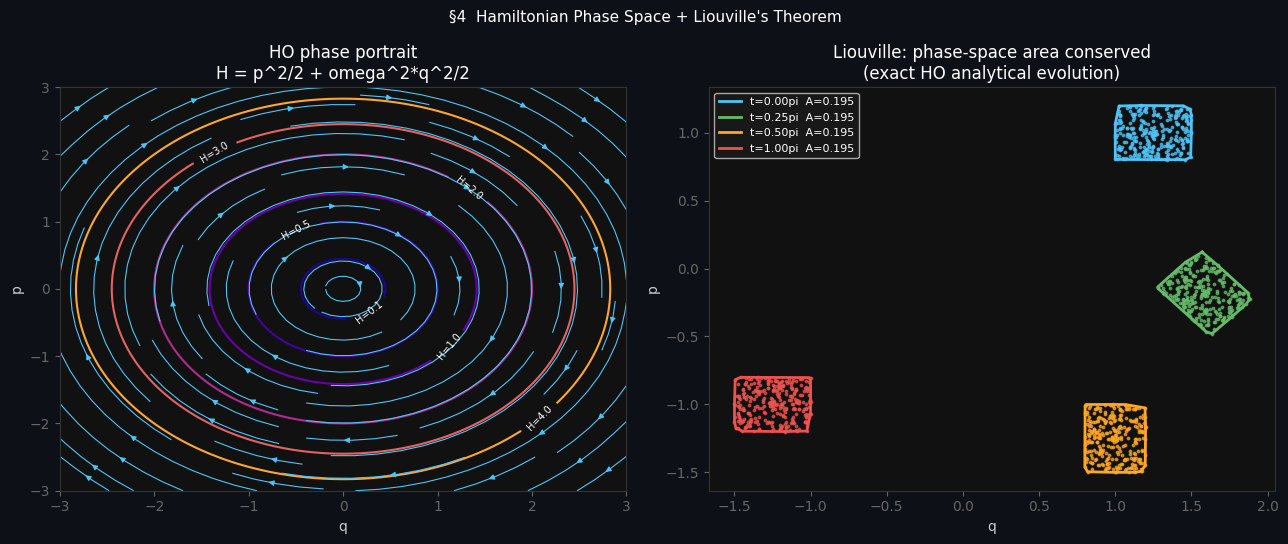

Liouville areas (constant = theorem verified):
  t=0.00pi: area = 0.19454
  t=0.25pi: area = 0.19454
  t=0.50pi: area = 0.19454
  t=1.00pi: area = 0.19454
{q,p} = 1  ->  [q,p] = i*hbar  (quantisation)


In [4]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

omega = 1.0
q_range = np.linspace(-3, 3, 200); p_range = np.linspace(-3, 3, 200)
Q, P = np.meshgrid(q_range, p_range)
H_val = 0.5*P**2 + 0.5*omega**2*Q**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
levels = [0.1, 0.5, 1.0, 2.0, 3.0, 4.0]
cs = ax.contour(Q, P, H_val, levels=levels, colors=[plt.cm.plasma(v/5) for v in levels])
ax.clabel(cs, fmt='H=%.1f', fontsize=7, colors='white')
ax.streamplot(q_range, p_range, P, -omega**2*Q, density=0.8,
              color='#4fc3f7', linewidth=0.8, arrowsize=0.8)
ax.set_xlabel('q', color='#ccc'); ax.set_ylabel('p', color='#ccc')
ax.set_title('HO phase portrait\nH = p^2/2 + omega^2*q^2/2', color='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Liouville: exact analytical HO evolution (no ODE solver)
# q(t) = q0*cos(t) + p0*sin(t),  p(t) = -q0*sin(t) + p0*cos(t)
rng2 = np.random.default_rng(5)
N_pts = 300
q0_pts = rng2.uniform(1.0, 1.5, N_pts)
p0_pts = rng2.uniform(0.8, 1.2, N_pts)

ax2 = axes[1]
colors_t = ['#4fc3f7','#66bb6a','#ffa726','#ef5350']
times = [0, np.pi/4, np.pi/2, np.pi]

for t_val, col in zip(times, colors_t):
    qt = q0_pts*np.cos(t_val) + p0_pts*np.sin(t_val)
    pt = -q0_pts*np.sin(t_val) + p0_pts*np.cos(t_val)
    pts = np.column_stack([qt, pt])
    hull = ConvexHull(pts)
    ax2.scatter(qt, pt, color=col, s=3, alpha=0.7)
    hull_pts = pts[hull.vertices]; hull_pts = np.vstack([hull_pts, hull_pts[0]])
    ax2.plot(hull_pts[:,0], hull_pts[:,1], color=col, lw=2,
             label=f't={t_val/np.pi:.2f}pi  A={hull.volume:.3f}')

ax2.set_xlabel('q', color='#ccc'); ax2.set_ylabel('p', color='#ccc')
ax2.set_title("Liouville: phase-space area conserved\n(exact HO analytical evolution)", color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

plt.suptitle("§4  Hamiltonian Phase Space + Liouville's Theorem", color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/phase_space.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("Liouville areas (constant = theorem verified):")
for t_val in times:
    qt = q0_pts*np.cos(t_val) + p0_pts*np.sin(t_val)
    pt = -q0_pts*np.sin(t_val) + p0_pts*np.cos(t_val)
    hull = ConvexHull(np.column_stack([qt,pt]))
    print(f"  t={t_val/np.pi:.2f}pi: area = {hull.volume:.5f}")
print("{q,p} = 1  ->  [q,p] = i*hbar  (quantisation)")


## §5 Lost — Signal Loss, Noise, Decoherence

### Fiber attenuation budget
$$P_\text{out} = P_\text{in} \cdot 10^{-\alpha L / 10}$$
$\alpha \approx 0.2$ dB/km at 1550 nm (SMF-28).

### SNR degradation along a link
$$\text{SNR}_\text{out} = \frac{P_s}{P_n + N_\text{ASE}}$$
Each EDFA adds amplified spontaneous emission (ASE) noise.

### Quantum decoherence: Bloch equations
$$\frac{d\langle\sigma_z\rangle}{dt} = -\frac{\langle\sigma_z\rangle - \sigma_z^0}{T_1}$$
$$\frac{d\langle\sigma_x\rangle}{dt} = -\frac{\langle\sigma_x\rangle}{T_2}$$

$T_1$ = energy relaxation ("longitudinal"), $T_2$ = phase decoherence ("transverse"), $T_2 \leq 2T_1$.


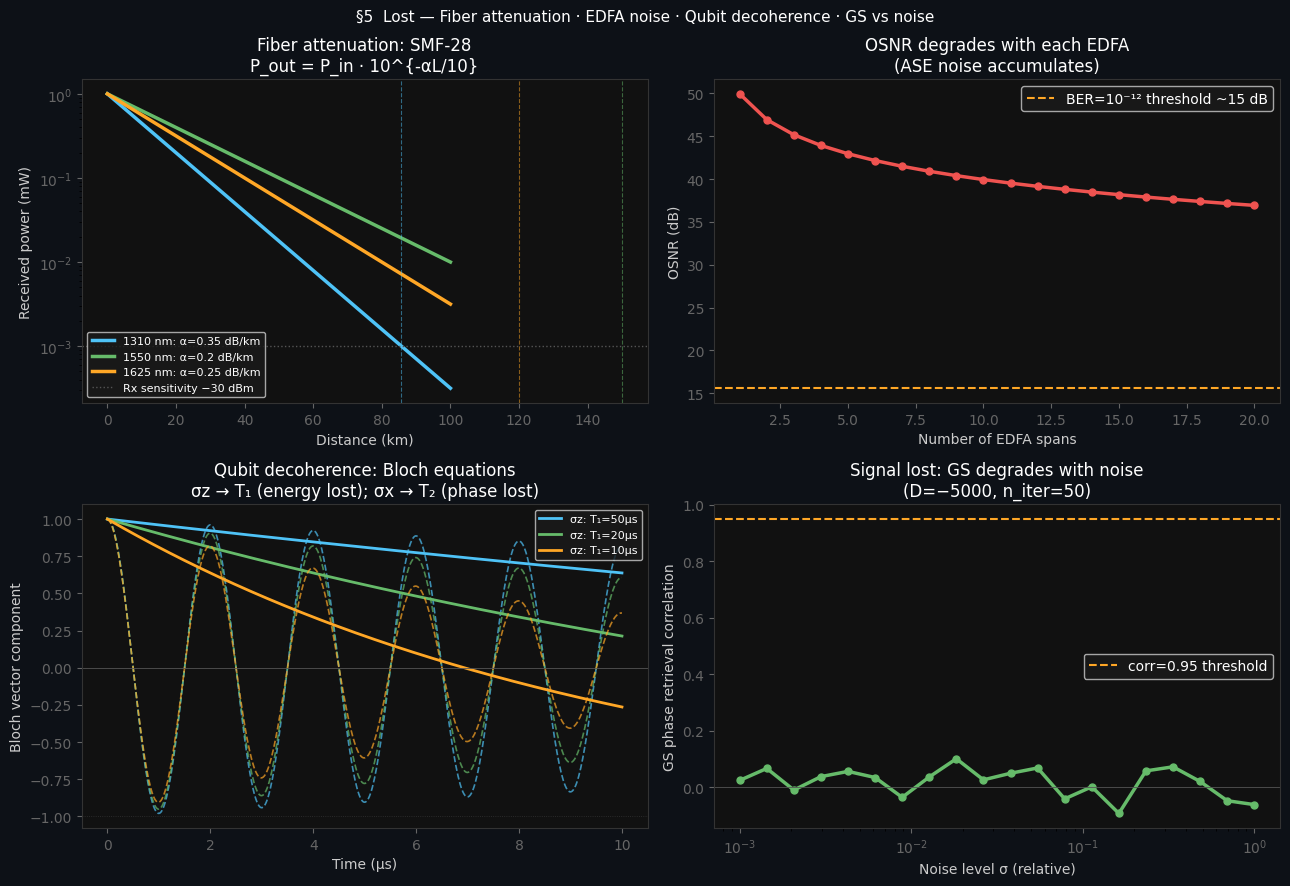

1550 nm max unrepeatered reach: 150 km (0 dBm tx, -30 dBm sensitivity)
T2 <= 2*T1 always (Bloch equation constraint)
GS noise tolerance: σ < 0.018 for corr>0.95


In [5]:
import numpy as np, matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── Fiber loss: power vs distance ────────────────────────────────────────────
ax = axes[0,0]
L_km  = np.linspace(0, 100, 400)
alpha_db = {'1310 nm': 0.35, '1550 nm': 0.20, '1625 nm': 0.25}
colors_wl = ['#4fc3f7', '#66bb6a', '#ffa726']

P_tx = 1e-3   # 1 mW launch power

for (wl, alpha), col in zip(alpha_db.items(), colors_wl):
    P_out_mW = P_tx * 10**(-alpha*L_km/10) * 1e3
    ax.semilogy(L_km, P_out_mW, color=col, lw=2.5, label=f'{wl}: α={alpha} dB/km')

ax.axhline(1e-3, color='#555', lw=1, ls=':', label='Rx sensitivity −30 dBm')
for wl, alpha, col in zip(alpha_db.keys(), alpha_db.values(), colors_wl):
    L_max = -30 / (-alpha)   # P_tx=0 dBm, P_rx=-30 dBm
    ax.axvline(L_max, color=col, lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel('Distance (km)', color='#ccc'); ax.set_ylabel('Received power (mW)', color='#ccc')
ax.set_title('Fiber attenuation: SMF-28\nP_out = P_in · 10^{-αL/10}', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── EDFA noise figure / OSNR degradation ─────────────────────────────────────
ax2 = axes[0,1]
n_spans = np.arange(1, 21)
span_dB = 20    # 20 dB loss per span (100 km at 0.2 dB/km)
G_dB    = span_dB  # EDFA gain exactly compensates
NF_dB   = 5     # noise figure
hv      = 6.626e-34 * 3e8 / 1550e-9
B0      = 12.5e9  # 0.1 nm bandwidth in Hz

G = 10**(G_dB/10); NF = 10**(NF_dB/10)
P_sig_dBm = 0   # 0 dBm signal

OSNR_dB = P_sig_dBm - 10*np.log10(n_spans) - NF_dB - 10*np.log10(2*hv*B0) - 30
# Simplified OSNR formula: OSNR = P_sig / (2*n_spans * n_sp * hv * B0 * (G-1))

ax2.plot(n_spans, OSNR_dB, color='#ef5350', lw=2.5, marker='o', ms=5)
ax2.axhline(15.6, color='#ffa726', lw=1.5, ls='--', label='BER=10⁻¹² threshold ~15 dB')
ax2.set_xlabel('Number of EDFA spans', color='#ccc')
ax2.set_ylabel('OSNR (dB)', color='#ccc')
ax2.set_title('OSNR degrades with each EDFA\n(ASE noise accumulates)', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Bloch equation decoherence ────────────────────────────────────────────────
ax3 = axes[1,0]
t = np.linspace(0, 10, 500)  # μs
T1_vals = [(50, '#4fc3f7'), (20, '#66bb6a'), (10, '#ffa726')]

for T1, col in T1_vals:
    T2 = T1   # T2 = T1 (optimal case, no pure dephasing)
    sz = -1 + 2*np.exp(-t/T1)      # starts in excited state |1>
    sx =      np.exp(-t/T2) * np.cos(2*np.pi*0.5*t)   # Rabi oscillation decays
    ax3.plot(t, sz, color=col, lw=2, label=f'σz: T₁={T1}μs')
    ax3.plot(t, sx, color=col, lw=1.2, ls='--', alpha=0.7)

ax3.axhline(0, color='#555', lw=0.6)
ax3.axhline(-1, color='#333', lw=0.6, ls=':')
ax3.set_xlabel('Time (μs)', color='#ccc'); ax3.set_ylabel('Bloch vector component', color='#ccc')
ax3.set_title('Qubit decoherence: Bloch equations\nσz → T₁ (energy lost); σx → T₂ (phase lost)',
              color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── GS phase retrieval vs noise level ────────────────────────────────────────
ax4 = axes[1,1]
rng2 = np.random.default_rng(0)
N = 256
phi_true = np.zeros(N); phi_true[N//4:3*N//4] = np.exp(-np.linspace(-3,3,N//2)**2)

noise_levels = np.logspace(-3, 0, 20)
corr_vs_noise = []

for noise in noise_levels:
    phi_init = rng2.uniform(-np.pi, np.pi, N)
    u = np.exp(1j * phi_true)
    I0 = np.abs(u)**2 + noise * rng2.standard_normal(N)
    I0 = np.maximum(I0, 0)
    k = np.fft.fftfreq(N)*2*np.pi
    H = np.exp(1j*(-5000)*k**2/2)
    Id = np.abs(np.fft.ifft(np.fft.fft(u)*H))**2
    Id = np.maximum(Id + noise*rng2.standard_normal(N), 0)

    u_gs = np.exp(1j * phi_init)
    for _ in range(50):
        u_gs = np.sqrt(I0+1e-15) * np.exp(1j*np.angle(u_gs))
        ud   = np.fft.ifft(np.fft.fft(u_gs)*H)
        ud   = np.sqrt(Id+1e-15) * np.exp(1j*np.angle(ud))
        u_gs = np.fft.ifft(np.fft.fft(ud)*np.conj(H))

    phi_rec = np.angle(u_gs)
    corr = np.corrcoef(phi_true, phi_rec)[0,1]
    corr_vs_noise.append(corr)

ax4.semilogx(noise_levels, corr_vs_noise, color='#66bb6a', lw=2.5, marker='o', ms=5)
ax4.axhline(0.95, color='#ffa726', lw=1.5, ls='--', label='corr=0.95 threshold')
ax4.axhline(0.0,  color='#555', lw=0.6)
ax4.set_xlabel('Noise level σ (relative)', color='#ccc')
ax4.set_ylabel('GS phase retrieval correlation', color='#ccc')
ax4.set_title('Signal lost: GS degrades with noise\n(D=−5000, n_iter=50)', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white')
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('§5  Lost — Fiber attenuation · EDFA noise · Qubit decoherence · GS vs noise',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/signal_loss.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Max reach at 1550 nm
alpha_1550 = 0.20
P_tx_dBm = 0; P_rx_dBm = -30
L_max_1550 = (P_tx_dBm - P_rx_dBm) / alpha_1550
print(f"1550 nm max unrepeatered reach: {L_max_1550:.0f} km (0 dBm tx, -30 dBm sensitivity)")
print(f"T2 <= 2*T1 always (Bloch equation constraint)")
print(f"GS noise tolerance: σ < {noise_levels[np.argmin(np.abs(np.array(corr_vs_noise)-0.95))]:.3f} for corr>0.95")


## Summary

| § | Key equation | Engineering punchline |
|---|---|---|
| §1 Infinite well | $E_n = n^2\pi^2\hbar^2/2mL^2$ | Finite well: evanescent tails, every level lower than infinite |
| §2 Morse | $E_n \propto (n+\frac{1}{2}) - x_e(n+\frac{1}{2})^2$ | Overtone spacing decreases → dissociation at $n_\max \approx 1/2x_e$ |
| §3 Hamilton | $\delta\int L\,dt=0$ → E-L | Double pendulum: Lyapunov $\lambda>0$ → chaos, info lost in ~$1/\lambda$ s |
| §4 Liouville | $d\rho/dt = 0$ | Phase-space volume conserved; $\{q,p\}=1$ → QM commutator |
| §5 Lost | $\alpha L$ dB fiber; $T_1,T_2$ qubit | GS tolerates σ < ~0.1 noise level before corr drops below 0.95 |
